In [1]:
# Filtering IOs code by Clement Ubelmann
## adapted to python function by Laura Gómez Navarro

import numpy
import matplotlib.pylab as plt
from datetime import datetime, timedelta
from netCDF4 import Dataset


# Trying for SVPB035 ... error as if was short but long!!

In [2]:
!ls /Users/Gomez023/src/git/FaSt-SWOT/data/drifters/L1_IMEDEA/

dep0001_drifter-svpb039_ime-svpb039_L1_2023-04-26.nc
drifter-svpb035.nc
drifter-svpb038.nc
drifter-svpb039.nc
drifter-svpb040.nc
drifter-svpb041.nc
drifter-svpb042.nc
drifter_carthe006-ime_carthe001.nc
drifter_carthe007-ime_carthe002.nc
drifter_carthe008-ime_carthe003.nc
drifter_carthe009-ime_carthe004.nc
drifter_carthe010-ime_carthe005.nc
drifter_carthe011-ime_carthe006.nc
drifter_carthe012-ime_carthe007.nc
drifter_carthe013-ime_carthe008.nc
drifter_carthe014-ime_carthe009.nc
drifter_carthe015-ime_carthe010.nc
drifter_carthe016-ime_carthe011.nc
drifter_carthe017-ime_carthe012.nc
drifter_carthe018-ime_carthe013.nc
drifter_carthe019-ime_carthe014.nc
drifter_carthe020-ime_carthe015.nc
drifter_carthe021-ime_carthe016.nc
drifter_carthe022-ime_carthe017.nc
drifter_carthe023-ime_carthe018.nc
drifter_carthe024-ime_carthe019.nc
drifter_carthe025-ime_carthe020.nc
drifter_hereon001-ime_hereon001.nc
drifter_hereon002-ime_hereon002.nc
drifter_hereon003-ime_hereon003.nc
drifter_hereon004-ime_hereon

In [3]:
filedir = "/Users/Gomez023/src/git/FaSt-SWOT/data/drifters/L1_IMEDEA/"
infile = filedir + 'drifter-svpb035.nc'
     

In [12]:
with Dataset(infile, 'r') as fcid:
    time = numpy.array(fcid.variables['time'][1:-1])*60*60 # seconds (originally in minutes)
    u = numpy.array(fcid.variables['U'][1:-1])
    v = numpy.array(fcid.variables['V'][1:-1])
    lat = numpy.array(fcid.variables['LAT'][1:-1])
    lon = numpy.array(fcid.variables['LON'][1:-1]) # added for plot below
## why ignoring first and last point?


In [13]:
time

array([    3600,     7200,    10800, ..., 15616800, 15620400, 15624000])

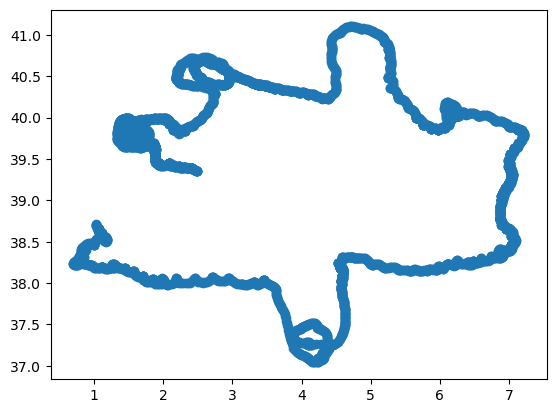

In [14]:
plt.scatter(lon, lat)
plt.show()

In [15]:
u.shape

(4340,)

In [8]:
((u.shape[0])) # * 10) / 60. # to get hours of drifter traj., sampling is 1 hr, so it is the shape

4340

In [9]:
24*3

72

# --> maybe ALSO problem is drifter is less than 3 days long?!

In [16]:
dt = time[1] - time[0]
dt # in seconds, for CARTHE time sampling is 10 mins, for SVP-B 1hr

3600

In [18]:
import xarray as xr
ds = xr.open_dataset(filedir + 'drifter-svpb035.nc')
ds

<xarray.Dataset>
Dimensions:  (time: 4342)
Coordinates:
  * time     (time) datetime64[ns] 2023-03-28T14:00:00 ... 2023-09-25T11:00:00
Data variables:
    LAT      (time) float64 ...
    LON      (time) float64 ...
    sst      (time) float64 ...
    slp      (time) float64 ...
    U        (time) float64 ...
    V        (time) float64 ...
Attributes: (12/69)
    title:                               Data from instrument SCB-SVPB035 on ...
    institution:                         SOCIB (Sistema de Observación y pred...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of surface drifter SCB-SV...
    summary:                             Deployment of surface drifter SCB-SV...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     National Oceanic and Atmospheric Adm...
    update_interval:                     every 7200 seconds
    DODS.strlen:                         30
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [ ]:
ds.time # --> yes confirmed it was 1 hour!

<xarray.DataArray 'time' (time: 4342)>
array(['2023-03-28T14:00:00.000000000', '2023-03-28T15:00:00.000000000',
       '2023-03-28T16:00:00.000000000', ..., '2023-09-25T09:00:00.000000000',
       '2023-09-25T10:00:00.000000000', '2023-09-25T11:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-03-28T14:00:00 ... 2023-09-25T11:00:00

# Continuing rest of code:

In [20]:
# Get real and imaginary part:
U = u + 1j*v
U

array([ 0.21248185+0.0556756j ,  0.03261257+0.04289405j,
       -0.07840113+0.02598823j, ..., -0.03340313+0.12910635j,
       -0.02744662+0.11469212j, -0.01974078+0.09312406j])

In [21]:
dt = time[1] - time[0]
dt # in seconds, for CARTHE time sampling is 10 mins, for SVP 1 hour

3600

$fc = 2 * 2 * \frac{\pi}{86164} * sin(mean(lat) * \frac{\pi}{180})$

In [22]:
fc = 2 * 2 * numpy.pi/86164 * numpy.sin(lat.mean() * numpy.pi/180)  # s-1
# earth's rotational period is 86164 s
fc

9.249871432518035e-05

In [23]:
time_conv = numpy.arange(-3*86400, 3*86400+dt, dt)
time_conv

array([-259200, -255600, -252000, -248400, -244800, -241200, -237600,
       -234000, -230400, -226800, -223200, -219600, -216000, -212400,
       -208800, -205200, -201600, -198000, -194400, -190800, -187200,
       -183600, -180000, -176400, -172800, -169200, -165600, -162000,
       -158400, -154800, -151200, -147600, -144000, -140400, -136800,
       -133200, -129600, -126000, -122400, -118800, -115200, -111600,
       -108000, -104400, -100800,  -97200,  -93600,  -90000,  -86400,
        -82800,  -79200,  -75600,  -72000,  -68400,  -64800,  -61200,
        -57600,  -54000,  -50400,  -46800,  -43200,  -39600,  -36000,
        -32400,  -28800,  -25200,  -21600,  -18000,  -14400,  -10800,
         -7200,   -3600,       0,    3600,    7200,   10800,   14400,
         18000,   21600,   25200,   28800,   32400,   36000,   39600,
         43200,   46800,   50400,   54000,   57600,   61200,   64800,
         68400,   72000,   75600,   79200,   82800,   86400,   90000,
         93600,   97

# --> why 3?

In [24]:
len(time_conv)

145

In [25]:
u.shape

(4340,)

In [26]:
len(time)

4340

$taul = 3 * fc^{-1}$

In [27]:
taul = 3 * fc**-1
taul

32432.883223149067

$gl = exp(-1j * fc * time\_conv) * exp(-taul^{-2} * (time\_conv)^2)$ 

numpy.exp..

$((\frac{gl^T}{\sum{d}})^T)^T$

In [28]:



# gl = 
# (numpy.exp(-1j*numpy.outer(fc[:],time_conv))*numpy.exp(-numpy.outer(taul**-2,time_conv**2))).reshape(len(time),len(time_conv))
gl = numpy.exp(-1j * fc * time_conv) * numpy.exp(-taul**-2 * time_conv**2)
gl = (gl.T / numpy.sum(numpy.abs(gl), axis=0).T).T

Unio = numpy.convolve(U, gl, 'same')

u_nio = numpy.real(Unio)
v_nio = numpy.imag(Unio)


In [29]:
u_nio.shape

(4340,)

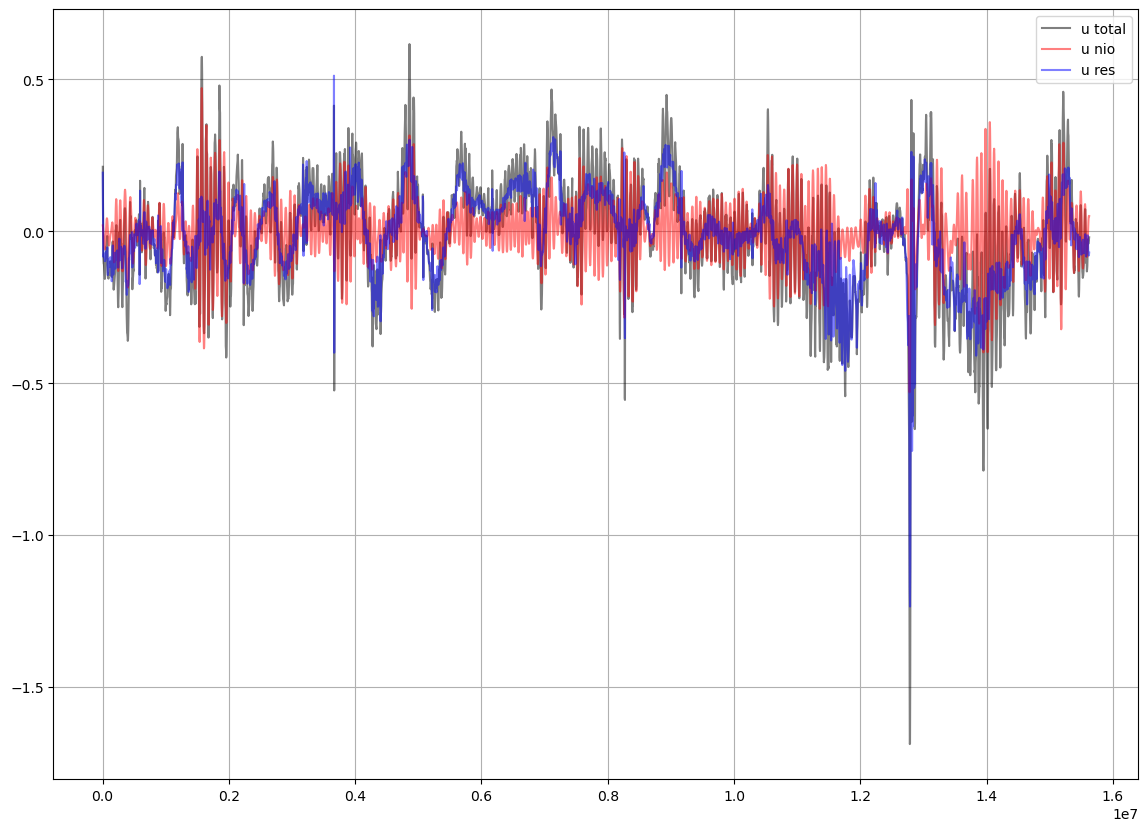

In [30]:
plt.figure(figsize=(14,10))
plt.plot(time, u, c='k', label='u total', alpha=0.5)
plt.plot(time, u_nio, c='r', label='u nio', alpha=0.5)
plt.plot(time, u - u_nio, c='b', label='u res', alpha=0.5)
plt.legend()
plt.grid()
plt.show()
# plt.savefig('drifter_laura.png')


In [31]:
len(u)

4340

In [32]:
len(time)

4340

In [33]:
len(u_nio)

4340